# Just visualize the kinematic maps that Antoine sent

In [261]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt

In [262]:
# the file is a csv with the format:
# X;Y;LOSV;LOSV_err;sigma;sigma_err;h3;h4
kin_table = Table.read("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/antoine/M104_stellar_Kin.csv", format="csv", delimiter=";")

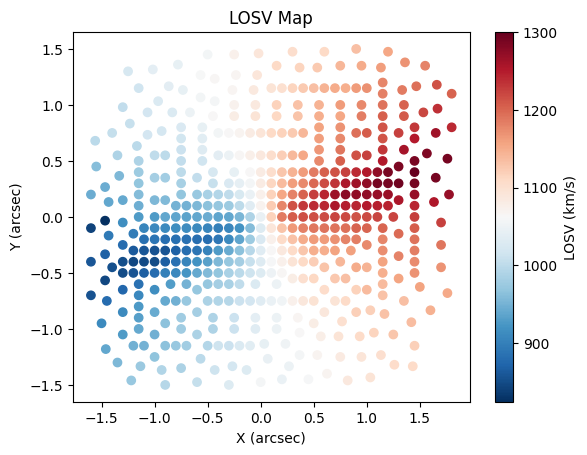

In [263]:
# make a plot just a scatter
plt.scatter(kin_table["X"], kin_table["Y"], c=kin_table["LOSV"], cmap="RdBu_r")
plt.colorbar(label="LOSV (km/s)")
plt.xlabel("X (arcsec)")
plt.ylabel("Y (arcsec)")
plt.title("LOSV Map")
#plt.savefig("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Notebooks/LOSV_map.png", dpi=600)
plt.show()

In [264]:
def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value', ax=None, show=True):
    # takes the xy and values and plots as an image with a colorbar
    # create a grid of x and y values
    xi = np.linspace(np.min(x), np.max(x), 100)
    yi = np.linspace(np.min(y), np.max(y), 100)
    xi, yi = np.meshgrid(xi, yi)
    # interpolate the values onto the grid
    from scipy.interpolate import griddata
    zi = griddata((x, y), values, (xi, yi), method='cubic')
    # plot the image
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)), origin='lower', cmap=cmap)
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    #ax.set_title('Interpolated Map')
    if show:
        plt.show()

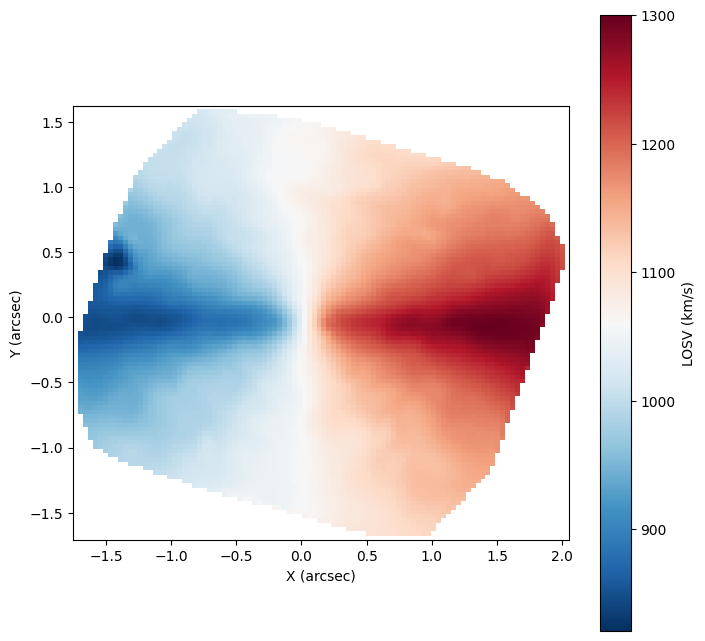

In [265]:
# this is not aligned with the photometry, it is in IFU alignment. We will need to rotate and shift it to match the photometry. The center is at (0, 0) in this table, which seems to match the center  of the galaxy.
# rotation to go from IFU alignment to photometry alignment is about 20 degrees.
def rotate(x, y, angle_deg):
    angle_rad = np.radians(angle_deg)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot
kin_table["X_rot"], kin_table["Y_rot"] = rotate(kin_table["X"],
                                                 kin_table["Y"], -18)

# plot the rotated LOSV map

plot_map(kin_table["X_rot"], kin_table["Y_rot"], kin_table["LOSV"], cbar_label='LOSV (km/s)') 


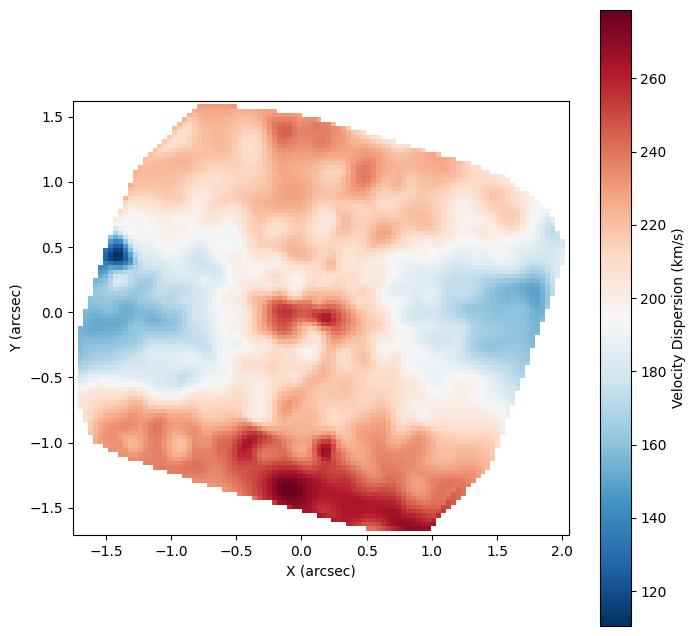

In [266]:
# plot the sigma
plot_map(kin_table["X_rot"], kin_table["Y_rot"], kin_table["sigma"], cbar_label='Velocity Dispersion (km/s)')
plt.show()

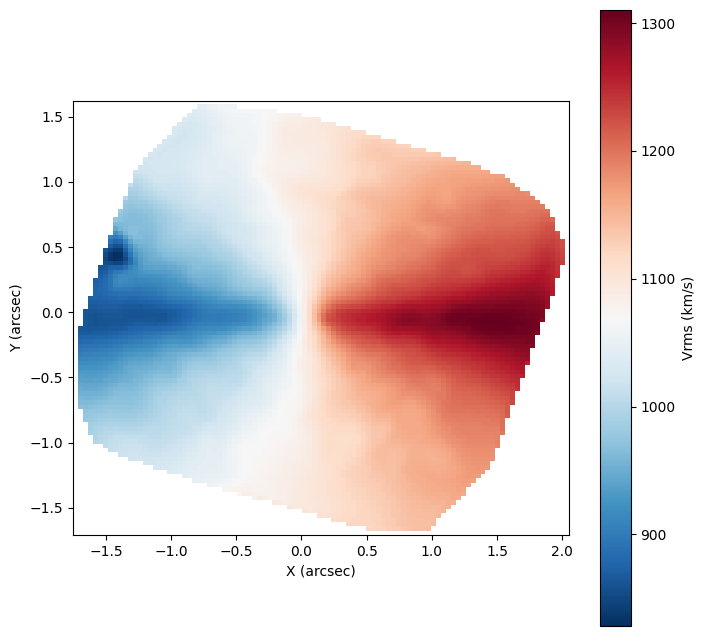

In [267]:
# plot the Vrms map
# get the xbin and ybin from the kinematics table
xbin = kin_table["X_rot"].data
ybin = kin_table["Y_rot"].data
# get the observed LOSV and sigma from the kinematics table
v_obs_lum = kin_table["LOSV"].data
sigma_obs_lum = kin_table["sigma"].data
# make the Vrms from the observed LOSV and sigma
vrms= np.sqrt(v_obs_lum**2 + sigma_obs_lum**2)
vrms_err = np.sqrt((v_obs_lum * kin_table["LOSV_err"].data)**2 + (sigma_obs_lum * kin_table["sigma_err"].data)**2) / vrms

# Vrms map
plot_map(kin_table["X_rot"], kin_table["Y_rot"], vrms, cbar_label='Vrms (km/s)')

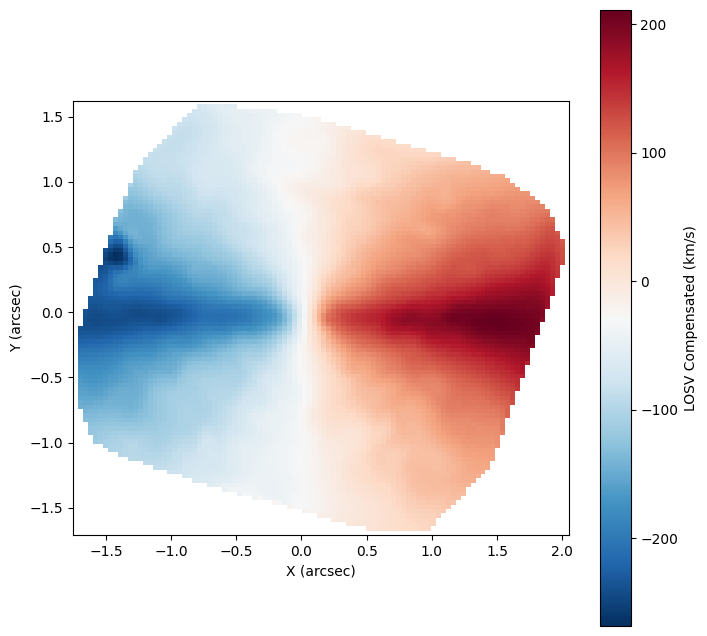

In [268]:
# compute line of sight velocity compensated by redshift
def compute_vlos_compensated(kin_table, z):
    c = 299792.458  # speed of light in km/s
    v_los_compensated = kin_table["LOSV"] - z * c
    return v_los_compensated

vlos_rf = compute_vlos_compensated(kin_table, z=0.003633)

# plot the LOSV compensated by redshift
plot_map(kin_table["X_rot"], kin_table["Y_rot"], vlos_rf, cbar_label='LOSV Compensated (km/s)')

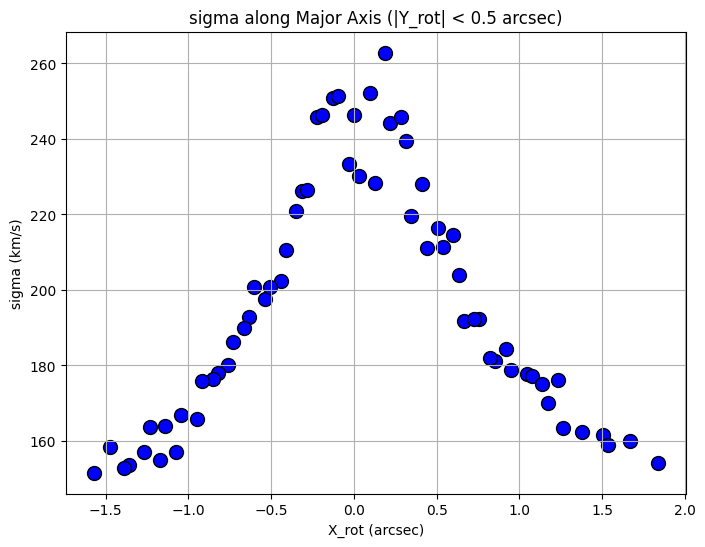

In [269]:
# make a pplot of the sigma values along the major axis (|Y_rot| < 0.5 arcsec)
plt.figure(figsize=(8, 6))
major_axis_mask = np.abs(kin_table["Y_rot"]) < 0.1
plt.scatter(kin_table["X_rot"][major_axis_mask], kin_table["sigma"][major_axis_mask], c="blue", s=100, edgecolor="k")
plt.xlabel("X_rot (arcsec)")
plt.ylabel("sigma (km/s)")
plt.title("sigma along Major Axis (|Y_rot| < 0.5 arcsec)")
plt.grid()
plt.show()

In [270]:
# save a new csv file with the rotated coordinates instead of the oriignal XY
kin_table_rotated = kin_table.copy()
kin_table_rotated["X"] = kin_table_rotated["X_rot"]
kin_table_rotated["Y"] = kin_table_rotated["Y_rot"]
kin_table_rotated.remove_columns(["X_rot", "Y_rot"])
kin_table_rotated.write("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/antoine/M104_stellar_Kin_rotated.csv", format="csv", delimiter=";", overwrite=True)

In [271]:
# load the MGE best fit
ARCSEC2_PER_SR = (180.0 / np.pi * 3600.0) ** 2
MAG_ARCSEC2_TO_LSUN_PC2 = 21.572
M_SUN_AB_F200W = 4.93             # adopted solar absolute AB magnitude
def gaussian_peak_from_total_counts(total_counts, sigma_pix, q_obs):
    """
    Convert the integrated MGE quantity produced by mgefit into the Gaussian peak.

    For a 2D elliptical Gaussian:
        total_counts = 2*pi*peak*sigma_pix^2*q_obs
    """
    return total_counts / (2.0 * np.pi * sigma_pix**2 * q_obs)



def mjysr_to_lsun_pc2(mu_mjysr, m_sun_ab=M_SUN_AB_F200W):
    """
    Convert surface brightness in MJy/sr into band luminosity surface density Lsun/pc^2.

    Uses:
        mu_AB[mag/arcsec^2] = -2.5*log10(I_nu[Jy/arcsec^2] / 3631)
        Sigma[Lsun/pc^2] = 10^[-0.4 * (mu_AB - M_sun_AB - 21.572)]
    """
    jy_arcsec2 = mu_mjysr * 1e6 / ARCSEC2_PER_SR
    mu_ab = -2.5 * np.log10(jy_arcsec2 / 3631.0)
    return 10.0 ** (-0.4 * (mu_ab - m_sun_ab - MAG_ARCSEC2_TO_LSUN_PC2))



def make_jam_mge_from_table(
    mge_tab,
    total_col="total_counts",
    sigma_pix_col="sigma_pix",
    q_col="q_obs",
    pixel_scale_arcsec=0.031,
    m_sun_ab= 4.93
):
    """Build the three JAM luminosity arrays from your MGE table."""
    sigma_pix = np.asarray(mge_tab[sigma_pix_col], dtype=float)
    q_obs = np.asarray(mge_tab[q_col], dtype=float)
    total_counts = np.asarray(mge_tab[total_col], dtype=float)

    peak_mjysr = gaussian_peak_from_total_counts(total_counts, sigma_pix, q_obs)
    surf_lum = mjysr_to_lsun_pc2(peak_mjysr, m_sun_ab=m_sun_ab)
    sigma_arcsec = sigma_pix * pixel_scale_arcsec

    return surf_lum, sigma_arcsec, q_obs

mge_tab = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_NAGN_0deg_pa_positive_gauss/mge_solution.csv')
surf_lum, sigma_lum, q_obs_lum = make_jam_mge_from_table(mge_tab)

In [272]:
# load the MGE best fit
mge_table = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_NAGN_0deg_pa_positive_gauss/mge_luminosity_table.csv')
mge_table
total_lum= mge_table['luminosity_Lsun']
# convert 
sigma_lum = mge_table['sigma_arcsec']
q_obs_lum = mge_table['q_obs']


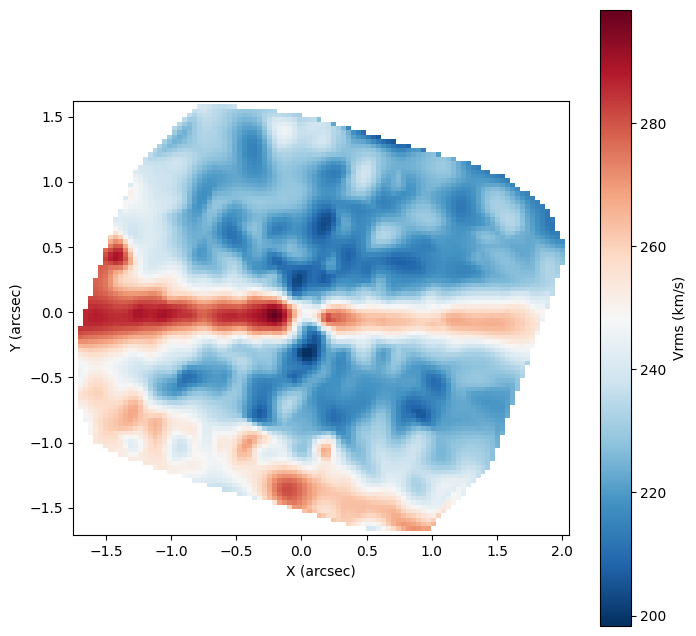

In [273]:

# get the xbin and ybin from the kinematics table
xbin = kin_table["X_rot"].data
ybin = kin_table["Y_rot"].data
# get the observed LOSV and sigma from the kinematics table
v_obs_lum = vlos_rf#kin_table["LOSV"].data
sigma_obs_lum = kin_table["sigma"].data
# make the Vrms from the observed LOSV and sigma
vrms= np.sqrt(v_obs_lum**2 + sigma_obs_lum**2)
vrms_err = np.sqrt((v_obs_lum * kin_table["LOSV_err"].data)**2 + (sigma_obs_lum * kin_table["sigma_err"].data)**2) / vrms

# plot the vrms 
plot_map(kin_table["X_rot"], kin_table["Y_rot"], vrms, cbar_label='Vrms (km/s)')

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_24148/2981659708.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plot_map(kin_table["X_rot"], kin_table["Y_rot"], sigma_obs_lum, cbar_label='$\sigma$ (km/s)')


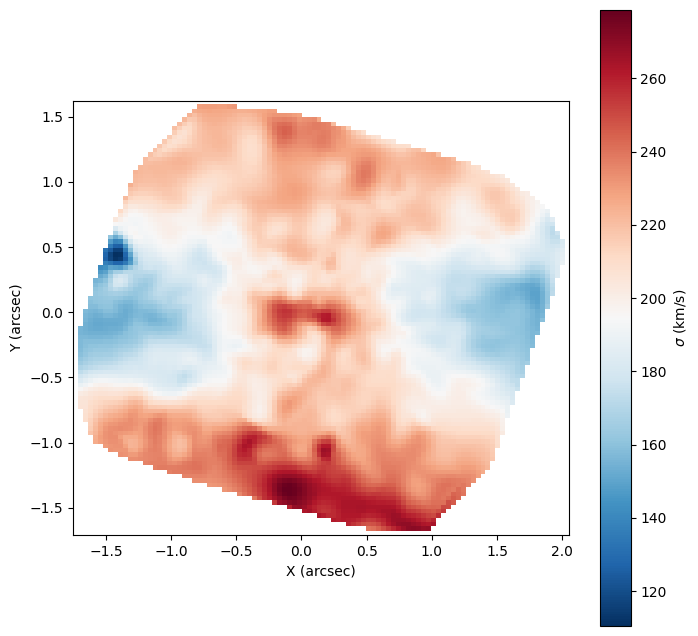

In [274]:

# get the xbin and ybin from the kinematics table
xbin = kin_table["X_rot"].data
ybin = kin_table["Y_rot"].data
# get the observed LOSV and sigma from the kinematics table
v_obs_lum = vlos_rf#kin_table["LOSV"].data
sigma_obs_lum = kin_table["sigma"].data
# make the Vrms from the observed LOSV and sigma
vrms= np.sqrt(v_obs_lum**2 + sigma_obs_lum**2)
vrms_err = np.sqrt((v_obs_lum * kin_table["LOSV_err"].data)**2 + (sigma_obs_lum * kin_table["sigma_err"].data)**2) / vrms

# plot the vrms 
plot_map(kin_table["X_rot"], kin_table["Y_rot"], sigma_obs_lum, cbar_label='$\sigma$ (km/s)')

jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 1.00
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.00; M/L=0.860; BH=2.2e+08; chi2/DOF=19.6
Total mass MGE (MSun): 1.162e+11



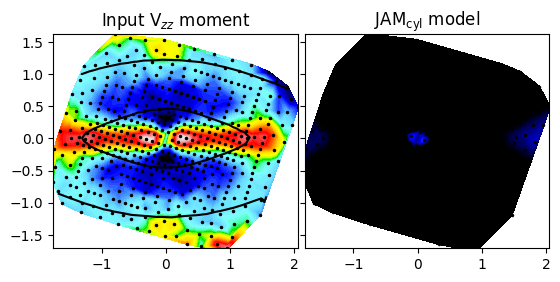

In [275]:
# import jampy and just evaluate the likelihood at some test parameters to make sure it works with the new kinematics file
import jampy as jam

# test parameters
bh_mass = 2.5e8 # from Jardel+2011
ml =  0.86# from stellar populations with MUSE

# make a goodbin mask to exclude the singularity at the center
goodbins = np.ones_like(vrms, dtype=bool)
goodbins[np.sqrt(xbin**2 + ybin**2) < 0.1] = False
# lets just remove that central bin at (0, 0)
goodbins[xbin == 0] = False
goodbins[ybin == 0] = False
# not just mask it out simply remove it
vlos = v_obs_lum[goodbins]
vrms = vrms[goodbins]
vrms_err = vrms_err[goodbins]
xbin = xbin[goodbins]
ybin = ybin[goodbins]
goodbins = goodbins[goodbins]
out = jam.axi.proj(
         surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
         inc=87.0, mbh=bh_mass, distance=9.55, xbin=xbin, ybin=ybin, align='cyl', analytic_los=False,
         beta=None, data=vrms, epsrel=1e-2, errors=vrms_err, flux_obs=None,
         gamma=None, goodbins=goodbins, interp=False, kappa=None,
         logistic=False, ml=ml, moment='zz',
         )

vrms_model = out.model  # with moment='zz' the output is the LOS Vrms
#vlos_model = out.model  # with moment='z' the output is the LOS velocity

out.plot()   # Generate data/model comparison when data is given

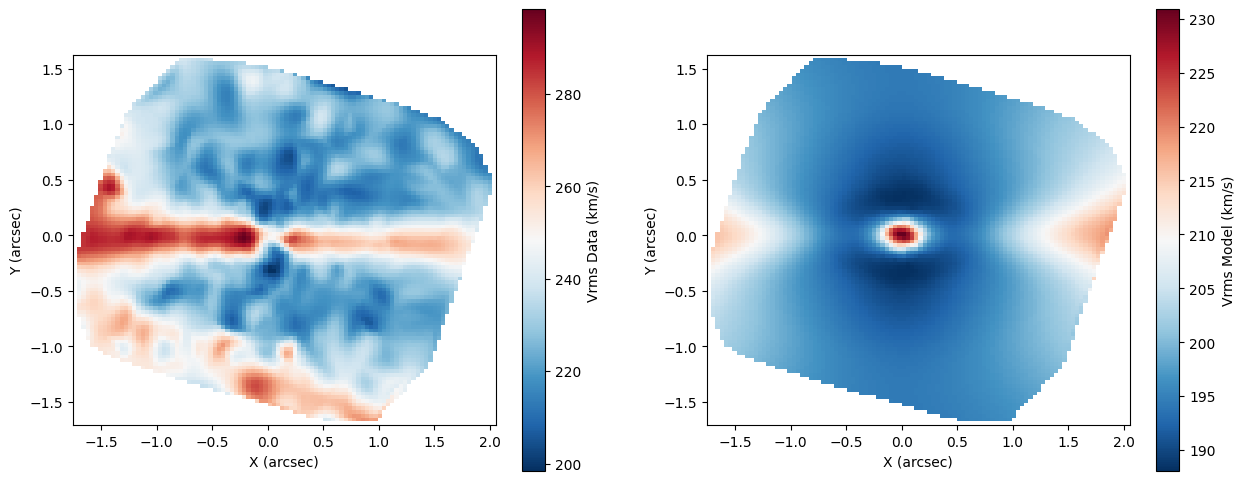

In [276]:
# plot the vrms data and model
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
plot_map(xbin, ybin, vrms, cbar_label='Vrms Data (km/s)', ax=ax[0], show=False)
plot_map(xbin, ybin, vrms_model, cbar_label='Vrms Model (km/s)', ax=ax[1], show=False)
plt.show()


jam.axi.proj(align='sph', moment='z') -- elapsed time sec: 1.96
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.19; M/L=1.00; BH=6.6e+08; chi2/DOF=12.1
Total mass MGE (MSun): 1.351e+11



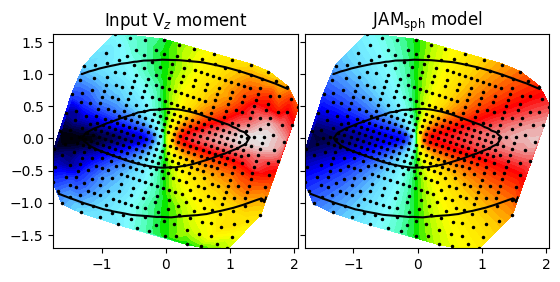

In [277]:
# import jampy and just evaluate the likelihood at some test parameters to make sure it works with the new kinematics file
import jampy as jam

# test parameters
bh_mass = 6.6e8 #2.5e8 # from Jardel+2011
ml =  0.86# from stellar populations with MUSE


# get the values from the table
xbin = kin_table["X_rot"].data
ybin = kin_table["Y_rot"].data
# make a goodbin mask to exclude the singularity at the center
goodbins = np.ones_like(kin_table["LOSV"], dtype=bool)
#goodbins[np.sqrt(xbin**2 + ybin**2) < 0.1] = False
# lets just remove that central bin at (0, 0)
goodbins[xbin == 0] = False
goodbins[ybin == 0] = False

# vrms
vlos_rf = compute_vlos_compensated(kin_table, z=0.003633)
vrms= np.sqrt(vlos_rf**2 + kin_table["sigma"].data**2)
vrms_err = np.sqrt((vlos_rf * kin_table["LOSV_err"].data)**2 + (kin_table["sigma"].data * kin_table["sigma_err"].data)**2) / vrms

# not just mask it out simply remove it

vlos_rf_masked = vlos_rf[goodbins]
vlos_rf_err = kin_table["LOSV_err"].data[goodbins]
vrms = vrms[goodbins]
vrms_err = vrms_err[goodbins]
xbin = xbin[goodbins]
ybin = ybin[goodbins]
goodbins = goodbins[goodbins]

out = jam.axi.proj(
         surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
         inc=87.0, mbh=bh_mass, distance=9.55, xbin=xbin, ybin=ybin, align='sph', analytic_los=False,
         beta=None, data=vlos_rf_masked, epsrel=1e-2, errors=vlos_rf_err, flux_obs=None,
         gamma=None, goodbins=goodbins, interp=False, kappa=None,
         logistic=False, ml=ml, moment='z',
         )

#vrms_model = out.model  # with moment='zz' the output is the LOS Vrms
vlos_model = out.model  # with moment='z' the output is the LOS velocity

out.plot()   # Generate data/model comparison when data is given

np.float64(12.07185272351908)

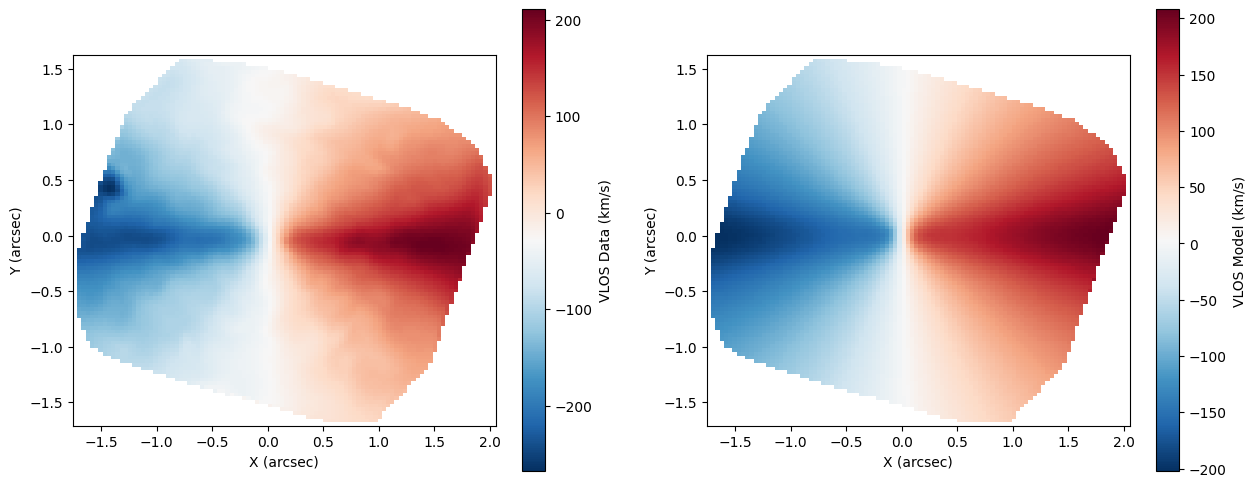

In [121]:
# plot the vlos data and model
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
plot_map(xbin, ybin, vlos_rf_masked, cbar_label='VLOS Data (km/s)', ax=ax[0], show=False)
plot_map(xbin, ybin, vlos_model, cbar_label='VLOS Model (km/s)', ax=ax[1], show=False)
plt.show()

In [330]:
out = jam.axi.proj(
         surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
         inc=87.0, mbh=0., distance=9.55, xbin=xbin, ybin=ybin, align='sph', analytic_los=False,
         beta=None, data=vrms, epsrel=1e-2, errors=vrms_err, flux_obs=None,
         gamma=None, goodbins=goodbins, interp=False, kappa=None,
         logistic=False, ml=ml, moment='zz',
         )

vrms_model = out.model  # with moment='zz' the output is the LOS Vrms
#vlos_model = out.model  # with moment='z' the output is the LOS velocity

out.plot()   # Generate data/model comparison when data is given

AssertionError: (rms, erms, goodbins) and (xbin, ybin) do not match

In [241]:
#import jam
import inspect
print(inspect.getfile(jam.axi.proj))

/Users/mncavieres/opt/anaconda3/envs/ppxf_env/lib/python3.14/site-packages/jampy/axi/jam_axi_proj.py


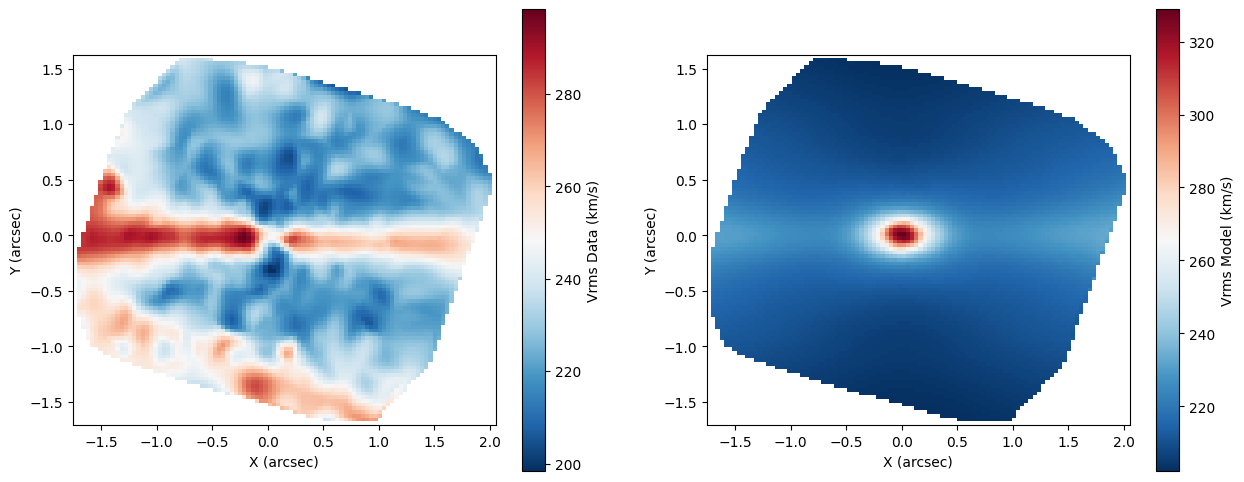

In [123]:
# plot vrms data and model
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
plot_map(xbin, ybin, vrms, cbar_label='Vrms Data (km/s)', ax=ax[0], show=False)
plot_map(xbin, ybin, vrms_model, cbar_label='Vrms Model (km/s)', ax=ax[1], show=False)
plt.show()

## Fit $V_{rms}$

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 3.19
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.00; M/L=1.00; BH=1.0e+08; chi2/DOF=16.9
Total mass MGE (MSun): 1.351e+11

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 2.46
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.00; M/L=1.00; BH=1.7e+08; chi2/DOF=13.4
Total mass MGE (MSun): 1.351e+11

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 2.85
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.00; M/L=1.00; BH=2.5e+08; chi2/DOF=10.5
Total mass MGE (MSun): 1.351e+11

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 2.31
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 

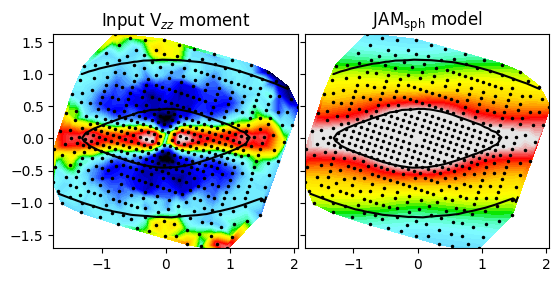

In [180]:
# do chi2 minimization to find the best fit BH mass
def chi2(mbh):
    out = jam.axi.proj(
             surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
             inc=87.0, mbh=mbh, distance=9.55, xbin=xbin, ybin=ybin, align='sph', analytic_los=False,
             beta=None, data=vrms, epsrel=1e-2, errors=vrms_err, flux_obs=None,
             gamma=None, goodbins=goodbins, interp=False, kappa=None,
             logistic=False, ml=1, moment='zz',
             )
    vrms_model = out.model
    chi2 = np.sum(((vrms - vrms_model) / vrms_err)**2)
    return chi2

# now evaluate for BH masses from 1e8 to 1e9
mbh_grid = np.linspace(1e8, 1.5e9, 20)
chi2_grid = [chi2(mbh) for mbh in mbh_grid]


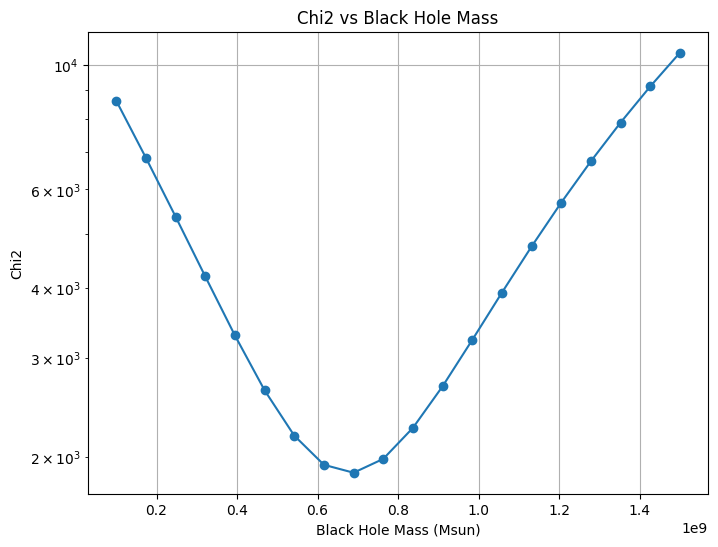

In [183]:
# plot the chi2 as a function of BH mass
plt.figure(figsize=(8, 6))
plt.plot(mbh_grid, chi2_grid, marker='o')
plt.xlabel('Black Hole Mass (Msun)')
plt.ylabel('Chi2')
plt.yscale('log')
plt.title('Chi2 vs Black Hole Mass')
plt.grid()

In [185]:
# get the best fit BH mass
best_mbh = mbh_grid[np.argmin(chi2_grid)]
print(f"Best fit BH mass: {best_mbh:.2e} Msun")

Best fit BH mass: 6.89e+08 Msun


## Fit Vlos

jam.axi.proj(align='sph', moment='z') -- elapsed time sec: 2.65
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.45; M/L=1.00; BH=1.0e+08; chi2/DOF=14.8
Total mass MGE (MSun): 1.351e+11

jam.axi.proj(align='sph', moment='z') -- elapsed time sec: 2.19
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.41; M/L=1.00; BH=1.7e+08; chi2/DOF=13.6
Total mass MGE (MSun): 1.351e+11

jam.axi.proj(align='sph', moment='z') -- elapsed time sec: 2.43
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0 interp=0
inc=87.0; beta[0]=0.0; kappa=1.37; M/L=1.00; BH=2.5e+08; chi2/DOF=12.8
Total mass MGE (MSun): 1.351e+11

jam.axi.proj(align='sph', moment='z') -- elapsed time sec: 2.17
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixs

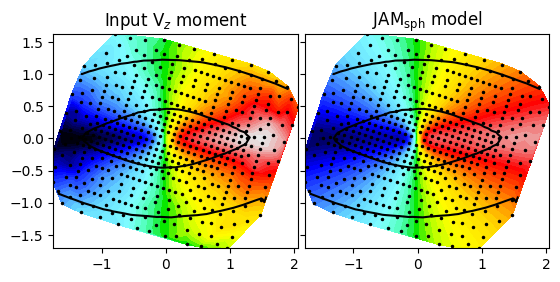

In [175]:
# now the same but fitting for the vlos instead of vrms
def chi2_vlos(mbh):
    out = jam.axi.proj(
            surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
            inc=87.0, mbh=mbh, distance=9.55, xbin=xbin, ybin=ybin, align='sph', analytic_los=False,
            beta=None, data=vlos_rf_masked, epsrel=1e-2, errors=vlos_rf_err, flux_obs=None,
            gamma=None, goodbins=goodbins, interp=False, kappa=None,
            logistic=False, ml=1, moment='z',
            )
    chi2 = out.chi2
    return chi2
mbh_grid= np.linspace(1e8, 1.5e9, 20)
chi2_vlos_grid = [chi2_vlos(mbh) for mbh in mbh_grid]


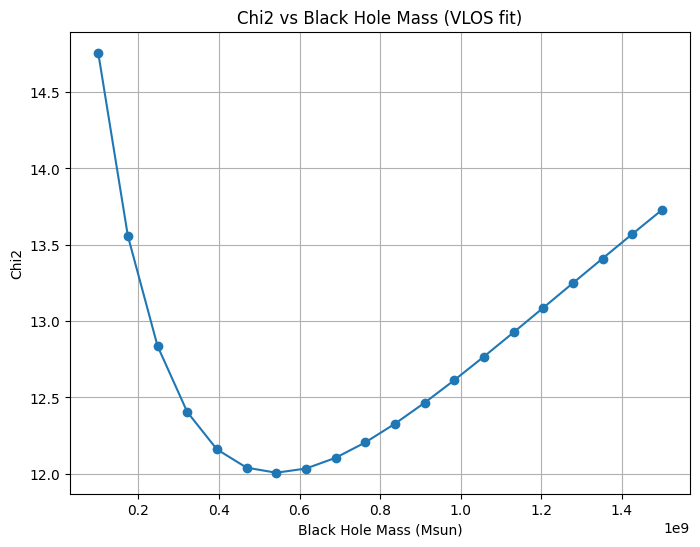

In [186]:
#plot the chi2 as a function of BH mass for the vlos fit
plt.figure(figsize=(8, 6))
plt.plot(mbh_grid, chi2_vlos_grid, marker='o')
plt.xlabel('Black Hole Mass (Msun)')
plt.ylabel('Chi2')
#plt.yscale('log')
plt.title('Chi2 vs Black Hole Mass (VLOS fit)')
plt.grid()

In [179]:
# print the best fit BH mass for the vlos fit and uncertainties from the hessian
best_mbh_vlos = mbh_grid[np.argmin(chi2_vlos_grid)]
print(f"Best fit BH mass (VLOS fit): {best_mbh_vlos:.2e} Msun")

# get uncertainties from the hessian by fitting a parabola to the chi2 values around the minimum
from scipy.optimize import curve_fit
def parabola(x, a, b, c):
    return a * (x - best_mbh_vlos)**2 + b * (x - best_mbh_vlos) + c
popt, pcov = curve_fit(parabola, mbh_grid, chi2_vlos_grid)
a, b, c = popt
mbh_uncertainty = np.sqrt(1 / (2 * a))
print(f"Uncertainty on BH mass (VLOS fit): {mbh_uncertainty:.2e} Msun")

Best fit BH mass (VLOS fit): 5.42e+08 Msun
Uncertainty on BH mass (VLOS fit): 3.64e+08 Msun


# Fit with PSF convolution


In [278]:
pc = 9.55*np.pi/0.648
print(f"surf_pot range: {surf_lum.min():.3e} to {surf_lum.max():.3e}")
print(f"sigma_pot range: {sigma_lum.min():.3e} to {sigma_lum.max():.3e} arcsec")
print(f"Manual mass: {(2*np.pi * surf_lum*0.86 * q_obs_lum * (sigma_lum*pc)**2).sum():.4e} Msun")

surf_pot range: 1.082e+02 to 1.824e+05
sigma_pot range: 2.182e-01 to 1.121e+02 arcsec
Manual mass: 1.3510e+11 Msun


In [281]:

# get the values from the table
xbin = kin_table["X_rot"].data
ybin = kin_table["Y_rot"].data

# vrms this time without masking
vlos_rf = compute_vlos_compensated(kin_table, z=0.003633)
vrms= np.sqrt(vlos_rf**2 + kin_table["sigma"].data**2)
vrms_err = np.sqrt((vlos_rf * kin_table["LOSV_err"].data)**2 + (kin_table["sigma"].data * kin_table["sigma_err"].data)**2) / vrms
# PSF: single Gaussian fitted to your NIRSpec/F200W PSF
# Measure this from a PSF star or WebbPSF; FWHM~0.066" -> sigma~0.028"
sigmapsf = np.array([0.12])   # arcsec
normpsf  = np.array([1.0])     # must sum to 1


jam.axi.proj(align='sph', moment='z') -- elapsed time sec: 1.63
analytic_los=0 logistic=0 constant_anisotropy=1
inc=87.0; beta[0]=0.0; kappa=1.19; M/L=1.00; BH=6.6e+08; chi2/DOF=12.3
Total mass MGE (MSun): 1.351e+11



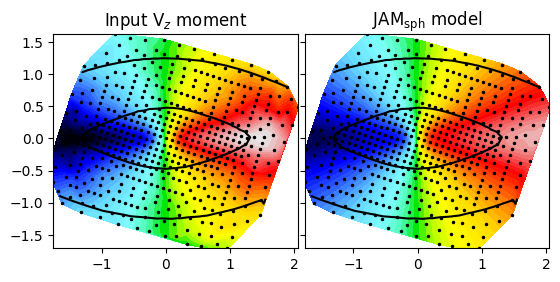

In [282]:
psf_fwhm = np.array([0.15])   # arcsec, FWHM~0.1" for NIRSpec at 2 micron
sigmapsf = psf_fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))  # convert FWHM to sigma
normpsf  = np.array([1.0])
bh_mass = 6.6e8 # from Jardel+2011

out = jam.axi.proj(
    surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum,
    surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
    inc=87.0, mbh=bh_mass, distance=9.55,
    xbin=xbin, ybin=ybin,
    align='sph', beta=None,
    data=vlos_rf, epsrel=1e-2,
    errors=kin_table["LOSV_err"].data,
    gamma=None, interp=True, kappa=None,
    logistic=False, ml=1, moment='z',
    sigmapsf=sigmapsf,
    normpsf=normpsf,
    pixsize=0.1, # NIRSpec pixel size is 0.1 arcsec, so we use that as the pixsize for the PSF convolution
    pixang=-18, # Rotation angle to align with the photometry
)

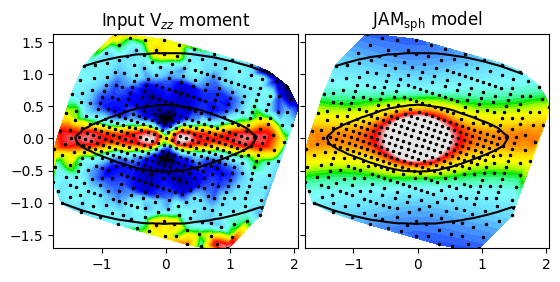

In [288]:
# do chi2 minimization to find the best fit BH mass

# get the values from the table
xbin = kin_table["X_rot"].data
ybin = kin_table["Y_rot"].data

# vrms
vlos_rf = compute_vlos_compensated(kin_table, z=0.003633)
vrms= np.sqrt(vlos_rf**2 + kin_table["sigma"].data**2)
vrms_err = np.sqrt((vlos_rf * kin_table["LOSV_err"].data)**2 + (kin_table["sigma"].data * kin_table["sigma_err"].data)**2) / vrms


def chi2_psf(mbh):
    out = jam.axi.proj(
            surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
            inc=87.0, mbh=mbh, distance=9.55, xbin=xbin, ybin=ybin, align='sph', analytic_los=False,
            beta=None, data=vrms, epsrel=1e-2, errors=vrms_err, flux_obs=None,
            gamma=None, 
            interp=True, kappa=None, 
            sigmapsf=0.1,
            normpsf= np.array([1.0]),
            pixsize=0.1, # NIRSpec pixel size is 0.1 arcsec, so we use that as the pixsize for the PSF convolution
            pixang=-18, # Rotation angle to align with the photometry 
            logistic=False, ml=1, moment='zz',
            quiet=True,  # Suppress output during chi2 evaluation
             )
    chi2 = out.chi2
    return chi2

# now evaluate for BH masses from 1e8 to 1e9
mbh_grid = np.linspace(0.5e8, 1e9, 25)
chi2_grid = [chi2_psf(mbh) for mbh in mbh_grid]


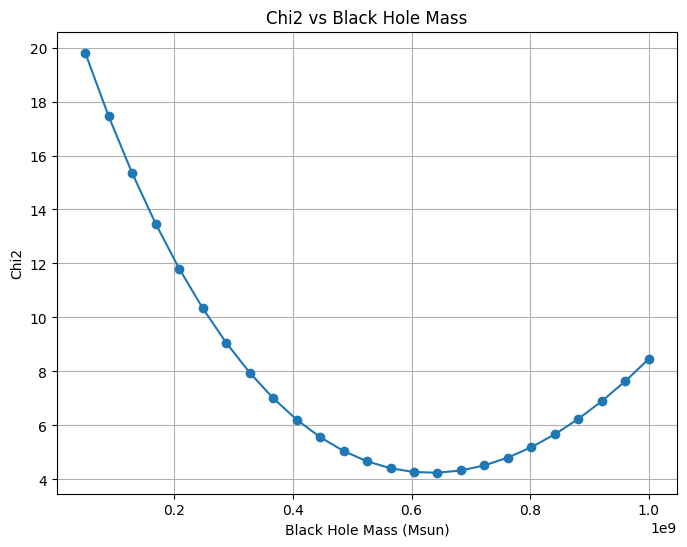

Best fit BH mass: 6.44e+08 Msun
Uncertainty on BH mass: 1.09e+08 Msun


In [289]:
# plot the chi2 as a function of BH mass
plt.figure(figsize=(8, 6))
plt.plot(mbh_grid, chi2_grid, marker='o')
plt.xlabel('Black Hole Mass (Msun)')
plt.ylabel('Chi2')
plt.title('Chi2 vs Black Hole Mass')
plt.grid()
plt.show()

print(f"Best fit BH mass: {mbh_grid[np.argmin(chi2_grid)]:.2e} Msun")
# fit a polynomial to the chi2 values to get the uncertainty on the BH mass using the second derivative at the minimum
from scipy.optimize import curve_fit
def parabola(x, a, b, c):
    return a * (x - mbh_grid[np.argmin(chi2_grid)])**2 + b * (x - mbh_grid[np.argmin(chi2_grid)]) + c
popt, pcov = curve_fit(parabola, mbh_grid, chi2_grid)
a, b, c = popt
mbh_uncertainty = np.sqrt(1 / (2 * a))
print(f"Uncertainty on BH mass: {mbh_uncertainty:.2e} Msun")

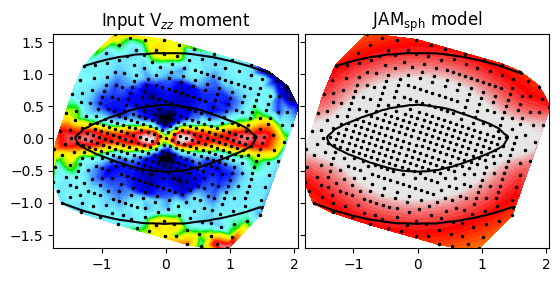

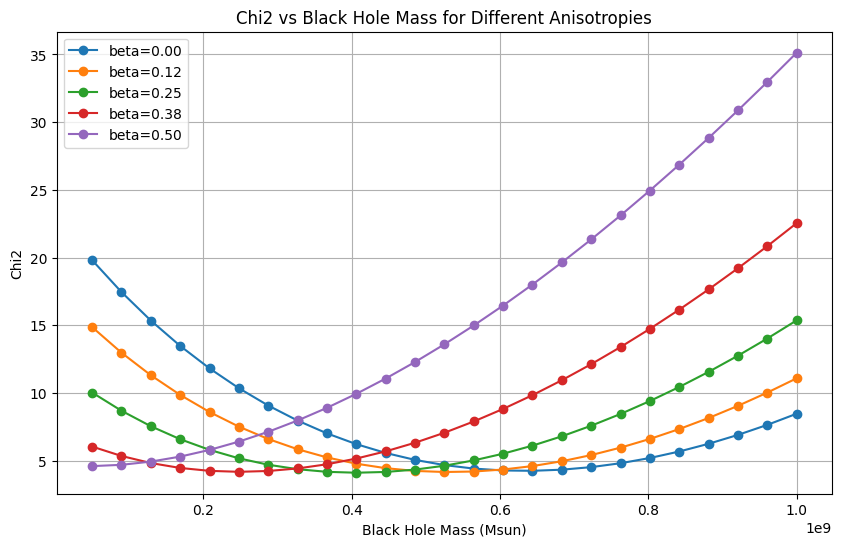

In [290]:
# what if I increase the anisotropy to beta=0.5?
def chi2_psf_beta(mbh, beta):
    # beta should be an array of the same length as the mge components
    beta = np.full_like(surf_lum, beta)
    out = jam.axi.proj(
            surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
            inc=87.0, mbh=mbh, distance=9.55, xbin=xbin, ybin=ybin, align='sph', analytic_los=False,
            beta=beta, data=vrms, epsrel=1e-2, errors=vrms_err, flux_obs=None,
            gamma=None, interp=True, kappa=None,
            sigmapsf=0.1,
            normpsf= np.array([1.0]),
            pixsize=0.1, # NIRSpec pixel size is 0.1 arcsec, so we use that as the pixsize for the PSF convolution
            pixang=-18, # Rotation angle to align with the photometry 
            logistic=False, ml=1, moment='zz',
            quiet=True,  # Suppress output during chi2 evaluation
             )
    chi2 = out.chi2
    return chi2

# now evaluate for BH masses from 1e8 to 1e9 and beta from 0 to 0.5
mbh_grid = np.linspace(0.5e8, 1e9, 25)
beta_grid = np.linspace(0, 0.5, 5)
chi2_grid = np.zeros((len(mbh_grid), len(beta_grid)))
for i, mbh in enumerate(mbh_grid):
    for j, beta in enumerate(beta_grid):
        chi2_grid[i, j] = chi2_psf_beta(mbh, beta)
# plot the chi2 as a function of BH mass and beta
plt.figure(figsize=(10, 6))
for j, beta in enumerate(beta_grid):
    plt.plot(mbh_grid, chi2_grid[:, j], marker='o', label=f'beta={beta:.2f}')
plt.xlabel('Black Hole Mass (Msun)')
plt.ylabel('Chi2')
plt.title('Chi2 vs Black Hole Mass for Different Anisotropies')
plt.legend()
plt.grid()
plt.show()

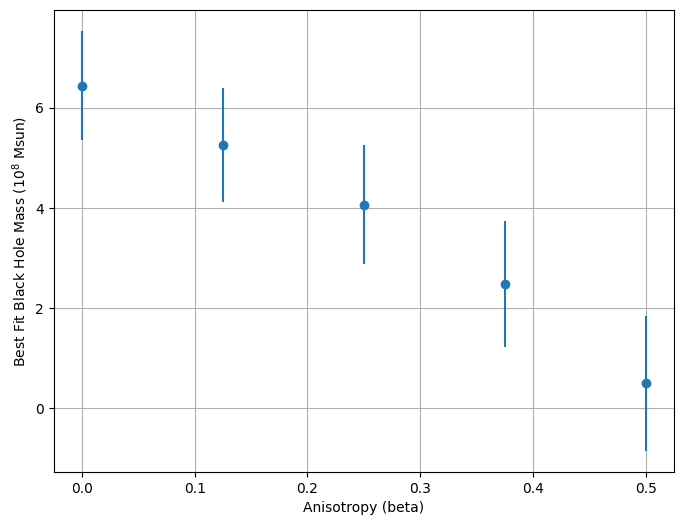

In [296]:
# plot the best fit mbh as a function of beta, with error bars from the chi2 parabola fit
# Note: make sure mbh_grid and chi2_grid are from cell 37
best_mbh_grid = np.zeros(len(beta_grid))
mbh_uncertainty_grid = np.zeros(len(beta_grid))
for j, beta in enumerate(beta_grid):
    min_idx = np.argmin(chi2_grid[:, j])
    best_mbh_grid[j] = mbh_grid[min_idx]
    # fit a parabola to the chi2 values to get the uncertainty on the BH mass using the second derivative at the minimum
    def parabola(x, a, b, c):
        return a * (x - best_mbh_grid[j])**2 + b * (x - best_mbh_grid[j]) + c
    popt, pcov = curve_fit(parabola, mbh_grid, chi2_grid[:, j])
    a, b, c = popt
    mbh_uncertainty_grid[j] = np.sqrt(1 / (2 * a))
plt.figure(figsize=(8, 6))
plt.errorbar(beta_grid, best_mbh_grid/1e8, yerr=mbh_uncertainty_grid/1e8, fmt='o')
plt.xlabel('Anisotropy (beta)')
plt.ylabel('Best Fit Black Hole Mass ($10^8$ Msun)')
#plt.title('Best Fit BH Mass vs Anisotropy')
plt.grid()
plt.show()

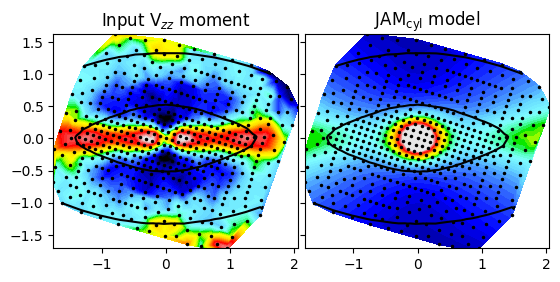

In [350]:
out = jam.axi.proj(
        surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
        inc=87.0, mbh=6e8, distance=9.55, xbin=xbin, ybin=ybin, align='cyl', analytic_los=False,
        #beta= np.full_like(surf_lum, -0.6),
         data=vrms, epsrel=1e-2, errors=vrms_err, flux_obs=None,
        gamma=None, interp=True, kappa=None,
        sigmapsf=0.1,
        normpsf= np.array([1.0]),
        pixsize=0.1, # NIRSpec pixel size is 0.1 arcsec, so we use that as the pixsize for the PSF convolution
        pixang=-18, # Rotation angle to align with the photometry 
        logistic=False, ml=1, moment='zz',
        quiet=True,  # Suppress output during chi2 evaluation
            )
vrms_model = out.model  # with moment='zz' the output is the LOS Vrms
#vlos_model = out.model  # with moment='z' the output is the LOS


# Load the dynesty fit and check out results

In [356]:
import dynesty
from dynesty import NestedSampler

output_dir = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/jam_models'

# load the kin_table
# the file is a csv with the format:
# X;Y;LOSV;LOSV_err;sigma;sigma_err;h3;h4
kin_table = Table.read("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/antoine/M104_stellar_Kin.csv", format="csv", delimiter=";")

# helper functions
def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value', ax=None, show=True):
    """
    Utility function to plot a 2D map of values at given x, y coordinates.
    Uses interpolation to create a smooth image from scattered data points.
    """
    # takes the xy and values and plots as an image with a colorbar
    # create a grid of x and y values
    xi = np.linspace(np.min(x), np.max(x), 100)
    yi = np.linspace(np.min(y), np.max(y), 100)
    xi, yi = np.meshgrid(xi, yi)
    # interpolate the values onto the grid
    from scipy.interpolate import griddata
    zi = griddata((x, y), values, (xi, yi), method='cubic')
    # plot the image
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)), origin='lower', cmap=cmap)
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    #ax.set_title('Interpolated Map')
    if show:
        plt.show()

# load the MGE best fit
ARCSEC2_PER_SR = (180.0 / np.pi * 3600.0) ** 2
MAG_ARCSEC2_TO_LSUN_PC2 = 21.572
M_SUN_AB_F200W = 4.93             # adopted solar absolute AB magnitude
def gaussian_peak_from_total_counts(total_counts, sigma_pix, q_obs):
    """
    Convert the integrated MGE quantity produced by mgefit into the Gaussian peak.

    For a 2D elliptical Gaussian:
        total_counts = 2*pi*peak*sigma_pix^2*q_obs
    """
    return total_counts / (2.0 * np.pi * sigma_pix**2 * q_obs)



def mjysr_to_lsun_pc2(mu_mjysr, m_sun_ab=M_SUN_AB_F200W):
    """
    Convert surface brightness in MJy/sr into band luminosity surface density Lsun/pc^2.

    Uses:
        mu_AB[mag/arcsec^2] = -2.5*log10(I_nu[Jy/arcsec^2] / 3631)
        Sigma[Lsun/pc^2] = 10^[-0.4 * (mu_AB - M_sun_AB - 21.572)]
    """
    jy_arcsec2 = mu_mjysr * 1e6 / ARCSEC2_PER_SR
    mu_ab = -2.5 * np.log10(jy_arcsec2 / 3631.0)
    return 10.0 ** (-0.4 * (mu_ab - m_sun_ab - MAG_ARCSEC2_TO_LSUN_PC2))



def make_jam_mge_from_table(
    mge_tab,
    total_col="total_counts",
    sigma_pix_col="sigma_pix",
    q_col="q_obs",
    pixel_scale_arcsec=0.031,
    m_sun_ab= 4.93
):
    """Build the three JAM luminosity arrays from your MGE table."""
    sigma_pix = np.asarray(mge_tab[sigma_pix_col], dtype=float)
    q_obs = np.asarray(mge_tab[q_col], dtype=float)
    total_counts = np.asarray(mge_tab[total_col], dtype=float)

    peak_mjysr = gaussian_peak_from_total_counts(total_counts, sigma_pix, q_obs)
    surf_lum = mjysr_to_lsun_pc2(peak_mjysr, m_sun_ab=m_sun_ab)
    sigma_arcsec = sigma_pix * pixel_scale_arcsec

    return surf_lum, sigma_arcsec, q_obs

# this is not aligned with the photometry, it is in IFU alignment. We will need to rotate and shift it to match the photometry. The center is at (0, 0) in this table, which seems to match the center  of the galaxy.
# rotation to go from IFU alignment to photometry alignment is about 20 degrees.
def rotate(x, y, angle_deg):
    angle_rad = np.radians(angle_deg)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot

# rotate the x and y coordinates in the kinematics table to align the kinematics
kin_table["X_rot"], kin_table["Y_rot"] = rotate(kin_table["X"],
                                                 kin_table["Y"], -18)

# get the xbin and ybin from the kinematics table
xbin = kin_table["X_rot"].data
ybin = kin_table["Y_rot"].data
# get the observed LOSV and sigma from the kinematics table
v_obs_lum = kin_table["LOSV"].data
sigma_obs_lum = kin_table["sigma"].data


# compute line of sight velocity compensated by redshift
def compute_vlos_compensated(kin_table, z):
    c = 299792.458  # speed of light in km/s
    v_los_compensated = kin_table["LOSV"] - z * c
    return v_los_compensated

vlos_rf = compute_vlos_compensated(kin_table, z=0.003633) # redshift of the Sombrero galaxy from NED


# make the Vrms from the observed LOSV and sigma
vrms= np.sqrt(vlos_rf**2 + sigma_obs_lum**2)
vrms_err = np.sqrt((vlos_rf * kin_table["LOSV_err"].data)**2 + (sigma_obs_lum * kin_table["sigma_err"].data)**2) / vrms

# load the MGE table

mge_tab = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_NAGN_0deg_pa_positive_gauss/mge_solution.csv')
surf_lum, sigma_lum, q_obs_lum = make_jam_mge_from_table(mge_tab) 

# load the MGE table

mge_tab = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_NAGN_0deg_pa_positive_gauss/mge_solution.csv')
surf_lum, sigma_lum, q_obs_lum = make_jam_mge_from_table(mge_tab) 

# load the MGE best fit
mge_table = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_NAGN_0deg_pa_positive_gauss/mge_luminosity_table.csv')
total_lum= mge_table['luminosity_Lsun']
# convert 
sigma_lum = mge_table['sigma_arcsec'] # for the JAM input we need the sigma in arcsec, not in pixels we already computed it before
q_obs_lum = mge_table['q_obs']

# now get the JAM
# import jampy and just evaluate the likelihood at some test parameters to make sure it works with the new kinematics file
import jampy as jam

# # test parameters
# bh_mass = 2.5e8 # from Jardel+2011
ml =  0.86# from stellar populations with MUSE

# 
def log_likelihood(params):
    bh_mass, r_a, gamma_0, gamma_inf, alpha, beta_0, beta_inf = params
    # bh mass in Msun
    # beta is the radial anisotropy of the individual kinematic-tracer MGE Gaussians (Default: beta=np.zeros(n)):
    beta = [r_a, beta_0, beta_inf, alpha]
    gamma = [r_a, gamma_0, gamma_inf, alpha]
    # gamma is the tangential anisotropy of the individual kinematic-tracer MGE Gaussians
    # gamma is a list of length equal to the number of Gaussians in the MGE,
    #  with one gamma value per Gaussian. This allows for more flexibility in the anisotropy profile,
    #  as each Gaussian can have its own tangential anisotropy.
    out = jam.axi.proj(
             surf_lum=surf_lum, sigma_lum=sigma_lum, qobs_lum=q_obs_lum, surf_pot=surf_lum*ml, sigma_pot=sigma_lum, qobs_pot=q_obs_lum,
             inc=87.0, mbh=bh_mass, distance=9.55, xbin=xbin, ybin=ybin, align='sph', analytic_los=False,
             beta=None, data=vrms, epsrel=1e-2, errors=vrms_err, flux_obs=None,
             gamma=None, 
             interp=True, kappa=None, 
             sigmapsf=0.1, # 0.1 arcsec is the PSF sigma, we can adjust this later if needed
             normpsf= np.array([1.0]), # normalized PSF
             pixsize=0.01, # NIRSpec pixel size is 0.1 arcsec, so we use that as the pixsize for the PSF convolution
             logistic=False, ml=1, moment='zz',
             quiet=True,  # Suppress output during chi2 evaluation
             )
    chi2 = out.chi2
    loglike = -0.5 * chi2
    return loglike

# we will now use dynesty to sample the posterior distribution of the parameters
from dynesty import DynamicNestedSampler
# define the prior transform function for dynesty


def prior_transform(utheta):
    # utheta is a unit cube in [0, 1]^D where D is the number of parameters
    # we need to transform it to the actual parameter space
    # we will use uniform priors for both parameters in the following ranges:
    bh_mass_min = 1e7
    bh_mass_max = 1e10

    bh_mass = bh_mass_min + utheta[0] * (bh_mass_max - bh_mass_min)

    # now define the priors for the anisotropy parameters, we will use uniform priors in the following ranges:
    r_a_min = 0.1
    r_a_max = 100.0
    gamma_0_min = -1.0
    gamma_0_max = 1.0
    gamma_inf_min = -1.0
    gamma_inf_max = 1.0
    alpha_min = 0.1
    alpha_max = 10.0
    beta_0_min = -1.0
    beta_0_max = 1.0
    beta_inf_min = -1.0
    beta_inf_max = 1.0

    r_a = r_a_min + utheta[1] * (r_a_max - r_a_min)
    gamma_0 = gamma_0_min + utheta[2] * (gamma_0_max - gamma_0_min)
    gamma_inf = gamma_inf_min + utheta[3] * (gamma_inf_max - gamma_inf_min)
    alpha = alpha_min + utheta[4] * (alpha_max - alpha_min)
    beta_0 = beta_0_min + utheta[5] * (beta_0_max - beta_0_min)
    beta_inf = beta_inf_min + utheta[6] * (beta_inf_max - beta_inf_min)

    return np.array([bh_mass, r_a, gamma_0, gamma_inf, alpha, beta_0, beta_inf])

# load the checkpoint file from the run
sampler = DynamicNestedSampler.restore('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/jam_models/constant_beta_bh/checkpoint.save')


In [357]:
sampler.run_nested(maxiter=1)

/Users/mncavieres/opt/anaconda3/envs/ppxf_env/lib/python3.14/site-packages/dynesty/dynamicsampler.py:1818: RuntimeWarning: You tried to run_nested() again from unclear sampler state. This is not supported. No sampling was performed.
  warnings.warn(


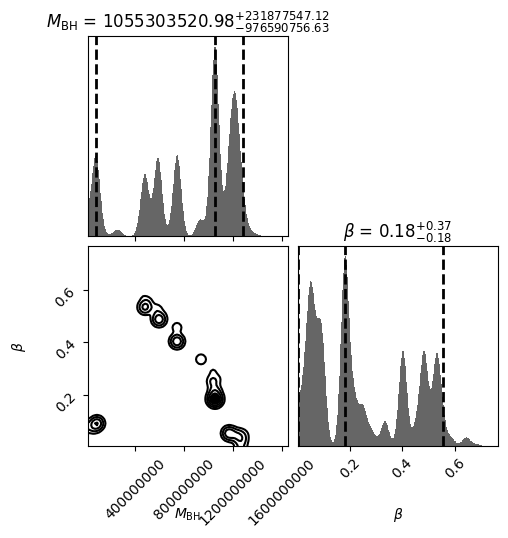

In [358]:
# make corner plots using dynesty's built in plotting functions
from dynesty import plotting as dyplot
# get the results from the sampler
res = sampler.results
# make a corner plot of the posterior distribution
labels = [r"$M_{\rm BH}$", r"$\beta$"]
fig, axes = dyplot.cornerplot(res, show_titles=True, labels=labels)
plt.savefig(f"{output_dir}/corner_plot.png", dpi=600)
plt.show()

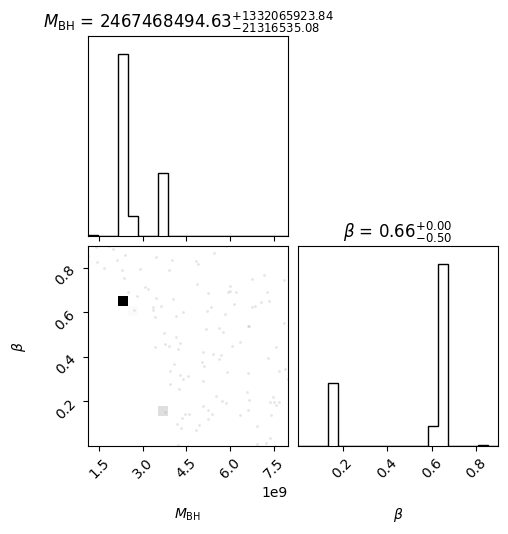

In [323]:
# remove samples with bh mass> 8e9 Msun
mask = res.samples[:, 0] < 8e9
samples_masked = res.samples[mask]
weights_masked = res.logwt[mask]
# make a corner plot of the masked posterior distribution using corner
import corner
labels = [r"$M_{\rm BH}$", r"$\beta$"]
fig = corner.corner(samples_masked, weights=np.exp(weights_masked - np.max(weights_masked)), labels=labels, show_titles=True)
plt.savefig(f"{output_dir}/corner_plot_masked.png", dpi=600)
plt.show()

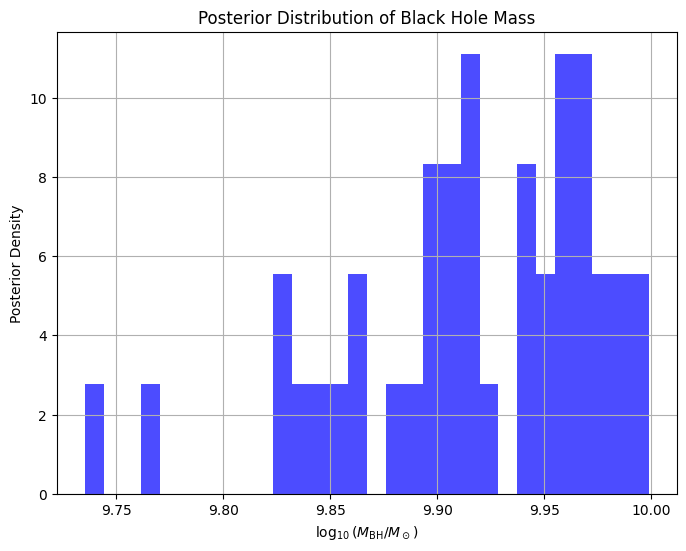

In [319]:
# plot the posterior distribution of the BH mass
plt.figure(figsize=(8, 6))
plt.hist(np.log10(res.samples[:, 0]), bins=30, density=True, alpha=0.7, color='blue')
plt.xlabel(r"$\log_{10}(M_{\rm BH} / M_\odot)$")
plt.ylabel("Posterior Density")
plt.title("Posterior Distribution of Black Hole Mass")
plt.grid()

In [164]:
# the best fit BH mass is the median of the posterior distribution
best_bh_mass = np.median(res.samples[:, 0])
bh_mass_16 = np.percentile(res.samples[:, 0], 16)
bh_mass_84 = np.percentile(res.samples[:, 0], 84)
print(f"Best fit BH mass: {best_bh_mass/1e9:.2} + {(bh_mass_84 - best_bh_mass)/1e9:.2} - {(best_bh_mass - bh_mass_16)/1e9:.2} e9 Msun")

Best fit BH mass: 1.4 + 3.8 - 0.57 e9 Msun


In [188]:
sampler_an = DynamicNestedSampler.restore('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/jam_models/constant_anisotropy/checkpoint_constant_anisotropy.save')

In [192]:
sampler_an.run_nested(maxiter=1)

/Users/mncavieres/opt/anaconda3/envs/ppxf_env/lib/python3.14/site-packages/dynesty/dynamicsampler.py:1818: RuntimeWarning: You tried to run_nested() again from unclear sampler state. This is not supported. No sampling was performed.
  warnings.warn(


In [196]:
# plot the corner of the results
results_an = sampler_an.results
labels = [r"$\log_{10}(M_{\rm BH} / M_\odot)$", r"$q_z = \sigma_z / \sigma_R$"]
# not enough points for contours so do a scatter 


ModuleNotFoundError: No module named 'corner'

In [ ]:
results_an